# CoT vs No-CoT Endpoint Hidden-State Experiments

This notebook analyzes endpoint hidden states saved under `outputs/triplet_endpoint_hidden_states`.

Main questions:

1. How large is the hidden-state shift from `non_thinking` to `thinking` across layers and conflict types?
2. Is the CoT shift mostly a low-rank shared direction, or type-specific?
3. Can endpoint hidden states predict thinking mode or judged outcomes under grouped cross-validation?
4. Do samples whose judged behavior changes between modes have larger or directionally different CoT shifts?
5. Are the effects explained by response length, reasoning length, or parse failures?

The notebook is intentionally defensive: it auto-discovers available models, handles missing judge outputs, and reports coverage before running downstream experiments.


In [1]:
from __future__ import annotations

import json
import math
import re
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

def find_repo_root(start: Path | None = None) -> Path:
    """Find the ConInstruct repo root even when Jupyter starts inside analysis/."""
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "outputs" / "triplet_endpoint_hidden_states").exists():
            return candidate
    for candidate in candidates:
        if (candidate / ".git").exists() and (candidate / "analysis").exists():
            return candidate
    return start


ROOT = find_repo_root()
HIDDEN_ROOT = ROOT / "outputs" / "triplet_endpoint_hidden_states"
EVAL_ROOT = ROOT / "evaluation_outputs" / "constraint_triplets"
OUT_DIR = ROOT / "analysis" / "cot_vs_nocot_endpoint_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

THINKING_MODES = ("non_thinking", "thinking")
CONDITION = "conflict"
RANDOM_STATE = 42

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("ROOT:", ROOT)
print("HIDDEN_ROOT exists:", HIDDEN_ROOT.exists())
print("EVAL_ROOT exists:", EVAL_ROOT.exists())
print("OUT_DIR:", OUT_DIR)


ROOT: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/ConInstruct-master
HIDDEN_ROOT exists: True
EVAL_ROOT exists: True
OUT_DIR: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/ConInstruct-master/analysis/cot_vs_nocot_endpoint_figures


## Helpers

The loaders below build one long metadata table and load layer matrices on demand. The important index is:

`model, thinking_mode, condition, conflict_type_idx, sample_id, row_idx`

`row_idx` is the row inside each `layer_*.npy` file; `sample_id` comes from `metadata.json`.


In [2]:
def read_json(path: Path) -> dict:
    with path.open(encoding="utf-8") as handle:
        return json.load(handle)


def safe_model_name(model: str) -> str:
    return model.replace("/", "__")


def canonical_model_from_dir(model_dir: Path) -> str:
    """Return model id relative to HIDDEN_ROOT, e.g. Qwen/Qwen3.5-4B or google/gemma-4-E4B-it."""
    return str(model_dir.relative_to(HIDDEN_ROOT))


def discover_model_dirs(hidden_root: Path = HIDDEN_ROOT) -> list[Path]:
    model_dirs = []
    for metadata in hidden_root.glob("**/metadata.json"):
        try:
            # Expected: <model>/<mode>/conflict/type_i/metadata.json.
            model_dir = metadata.parents[3]
            if (model_dir / "thinking").exists() or (model_dir / "non_thinking").exists():
                model_dirs.append(model_dir)
        except IndexError:
            continue
    return sorted(set(model_dirs), key=lambda p: str(p))


def layer_number(path: Path) -> int:
    match = re.search(r"layer_(\d+)\.npy$", path.name)
    if not match:
        raise ValueError(f"Not a layer file: {path}")
    return int(match.group(1))


HIDDEN_INDEX_COLUMNS = [
    "model", "model_dir", "thinking_mode", "enable_thinking", "condition",
    "conflict_type_idx", "sample_id", "row_idx", "type_dir", "layers", "n_layers",
    "prefix_length", "response_path", "task", "conflict_type", "finish_reason",
    "stop_reason", "prompt_length", "completion_length", "reasoning_chars",
    "final_answer_chars", "response_chars", "has_reasoning", "has_final_answer",
]


def load_hidden_index(hidden_root: Path = HIDDEN_ROOT) -> pd.DataFrame:
    rows = []
    for model_dir in discover_model_dirs(hidden_root):
        model = canonical_model_from_dir(model_dir)
        for mode in THINKING_MODES:
            mode_root = model_dir / mode / CONDITION
            if not mode_root.exists():
                continue
            for type_dir in sorted(mode_root.glob("type_*"), key=lambda p: int(p.name.split("_")[-1])):
                metadata_path = type_dir / "metadata.json"
                if not metadata_path.exists():
                    continue
                metadata = read_json(metadata_path)
                sample_ids = [int(x) for x in metadata.get("sample_ids", [])]
                prefix_lengths = metadata.get("prefix_lengths", [None] * len(sample_ids))
                layers = sorted(layer_number(p) for p in type_dir.glob("layer_*.npy"))
                if not layers:
                    continue
                ctype = int(type_dir.name.split("_")[-1])
                for row_idx, sample_id in enumerate(sample_ids):
                    response_path = type_dir / "responses" / f"{sample_id}.json"
                    response = read_json(response_path) if response_path.exists() else {}
                    reasoning = response.get("reasoning") or ""
                    final_answer = response.get("final_answer") or ""
                    full_response = response.get("response") or ""
                    rows.append({
                        "model": model,
                        "model_dir": str(model_dir),
                        "thinking_mode": mode,
                        "enable_thinking": response.get("enable_thinking", mode == "thinking"),
                        "condition": CONDITION,
                        "conflict_type_idx": ctype,
                        "sample_id": int(sample_id),
                        "row_idx": row_idx,
                        "type_dir": str(type_dir),
                        "layers": tuple(layers),
                        "n_layers": len(layers),
                        "prefix_length": prefix_lengths[row_idx] if row_idx < len(prefix_lengths) else None,
                        "response_path": str(response_path) if response_path.exists() else None,
                        "task": response.get("task"),
                        "conflict_type": response.get("conflict_type"),
                        "finish_reason": response.get("finish_reason"),
                        "stop_reason": response.get("stop_reason"),
                        "prompt_length": response.get("prompt_length"),
                        "completion_length": response.get("completion_length"),
                        "reasoning_chars": len(reasoning),
                        "final_answer_chars": len(final_answer),
                        "response_chars": len(full_response),
                        "has_reasoning": bool(reasoning.strip()),
                        "has_final_answer": bool(final_answer.strip()),
                    })
    frame = pd.DataFrame(rows, columns=HIDDEN_INDEX_COLUMNS)
    for col in ["prompt_length", "completion_length", "prefix_length"]:
        if col in frame:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")
    return frame


hidden_index = load_hidden_index()
print(hidden_index.shape)
hidden_index.head()


(5158, 24)


,model,model_dir,thinking_mode,enable_thinking,condition,conflict_type_idx,sample_id,row_idx,type_dir,layers,n_layers,prefix_length,response_path,task,conflict_type,finish_reason,stop_reason,prompt_length,completion_length,reasoning_chars,final_answer_chars,response_chars,has_reasoning,has_final_answer
0,Qwen/Qwen3.5-4B,/Users/xinmingwang/Library/CloudStorage/OneDri...,non_thinking,False,conflict,1,1,0,/Users/xinmingwang/Library/CloudStorage/OneDri...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32,66,/Users/xinmingwang/Library/CloudStorage/OneDri...,email writting,Conflicts between Content Constraints,stop,NaN,67,237,0,1155,1155,False,True
1,Qwen/Qwen3.5-4B,/Users/xinmingwang/Library/CloudStorage/OneDri...,non_thinking,False,conflict,1,2,1,/Users/xinmingwang/Library/CloudStorage/OneDri...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32,76,/Users/xinmingwang/Library/CloudStorage/OneDri...,email writting,Conflicts between Content Constraints,stop,NaN,77,191,0,948,948,False,True
2,Qwen/Qwen3.5-4B,/Users/xinmingwang/Library/CloudStorage/OneDri...,non_thinking,False,conflict,1,3,2,/Users/xinmingwang/Library/CloudStorage/OneDri...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32,65,/Users/xinmingwang/Library/CloudStorage/OneDri...,email writting,Conflicts between Content Constraints,stop,NaN,66,128,0,628,628,False,True
3,Qwen/Qwen3.5-4B,/Users/xinmingwang/Library/CloudStorage/OneDri...,non_thinking,False,conflict,1,4,3,/Users/xinmingwang/Library/CloudStorage/OneDri...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32,69,/Users/xinmingwang/Library/CloudStorage/OneDri...,email writting,Conflicts between Content Constraints,stop,NaN,70,185,0,1006,1006,False,True
4,Qwen/Qwen3.5-4B,/Users/xinmingwang/Library/CloudStorage/OneDri...,non_thinking,False,conflict,1,5,4,/Users/xinmingwang/Library/CloudStorage/OneDri...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32,54,/Users/xinmingwang/Library/CloudStorage/OneDri...,email writting,Conflicts between Content Constraints,stop,NaN,55,147,0,721,721,False,True


In [3]:
if hidden_index.empty:
    raise RuntimeError(
        "No endpoint hidden states were discovered. "
        f"ROOT={ROOT} HIDDEN_ROOT={HIDDEN_ROOT} exists={HIDDEN_ROOT.exists()}. "
        "Run the setup/helper cells again after this notebook update, and make sure the repo contains "
        "outputs/triplet_endpoint_hidden_states/**/layer_*.npy."
    )

coverage = (
    hidden_index.groupby(["model", "thinking_mode", "conflict_type_idx"])
    .agg(n_samples=("sample_id", "nunique"), n_layers=("n_layers", "max"), has_reasoning_rate=("has_reasoning", "mean"))
    .reset_index()
)
display(coverage.head(30))

summary = (
    hidden_index.groupby(["model", "thinking_mode"])
    .agg(
        n_rows=("sample_id", "size"),
        n_types=("conflict_type_idx", "nunique"),
        n_samples=("sample_id", "nunique"),
        min_layers=("n_layers", "min"),
        max_layers=("n_layers", "max"),
        reasoning_rate=("has_reasoning", "mean"),
        final_answer_rate=("has_final_answer", "mean"),
        median_completion_length=("completion_length", "median"),
    )
    .reset_index()
)
display(summary)
summary.to_csv(OUT_DIR / "00_hidden_state_coverage.csv", index=False)


,model,thinking_mode,conflict_type_idx,n_samples,n_layers,has_reasoning_rate
0,Qwen/Qwen3.5-4B,non_thinking,1,100,32,0.0
1,Qwen/Qwen3.5-4B,non_thinking,2,100,32,0.0
2,Qwen/Qwen3.5-4B,non_thinking,3,100,32,0.0
3,Qwen/Qwen3.5-4B,non_thinking,4,100,32,0.0
4,Qwen/Qwen3.5-4B,non_thinking,5,100,32,0.0
5,Qwen/Qwen3.5-4B,non_thinking,6,100,32,0.0
6,Qwen/Qwen3.5-4B,non_thinking,7,100,32,0.0
7,Qwen/Qwen3.5-4B,non_thinking,8,94,32,0.0
8,Qwen/Qwen3.5-4B,non_thinking,9,70,32,0.0
9,Qwen/Qwen3.5-4B,thinking,1,100,32,1.0


,model,thinking_mode,n_rows,n_types,n_samples,min_layers,max_layers,reasoning_rate,final_answer_rate,median_completion_length
0,Qwen/Qwen3.5-4B,non_thinking,864,9,100,32,32,0.0,1.0,340.0
1,Qwen/Qwen3.5-4B,thinking,861,9,100,32,32,1.0,1.0,4531.0
2,Qwen/Qwen3.5-9B,non_thinking,864,9,100,32,32,0.0,1.0,320.0
3,Qwen/Qwen3.5-9B,thinking,862,9,100,32,32,1.0,1.0,4476.5
4,google/gemma-4-E4B-it,non_thinking,864,9,100,42,42,0.0,1.0,568.5
5,google/gemma-4-E4B-it,thinking,843,9,100,42,42,1.0,1.0,1107.0


## Judge label loaders

This tries several known output layouts:

- `evaluation_outputs/constraint_triplets/<model>/<mode>/conflict/type_i/*.json`
- `evaluation_outputs/constraint_triplets/judge_*/<model>/<mode>/conflict/type_i/*.json`
- `evaluation_outputs/constraint_triplets/judge_*/conflict_resolution_behavior/<model>/<mode>/conflict/type_i/*.json`

The notebook keeps both constraint-following labels and behavior labels when available.


In [4]:
def parse_final_int(text: str, allowed: tuple[int, ...]) -> int:
    if not isinstance(text, str) or not text.strip():
        return -1
    allowed_set = set(allowed)
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    answer_pattern = re.compile(r"(?:answer|result)\D*(-?\d+)\D*$", re.IGNORECASE)
    for line in reversed(lines[-5:]):
        match = answer_pattern.search(line)
        if match and int(match.group(1)) in allowed_set:
            return int(match.group(1))
    for line in reversed(lines[-3:]):
        match = re.search(r"(-?\d+)\D*$", line)
        if match and int(match.group(1)) in allowed_set:
            return int(match.group(1))
    return -1


def label_from_eval_json(data: dict, behavior: bool) -> tuple[int, str]:
    if "label" in data and data.get("label") is not None:
        label = int(data["label"])
        name = data.get("label_name") or str(label)
        return label, name
    text = data.get("evaluation_result", "")
    if behavior:
        label = parse_final_int(text, (1, 2, 3, 4))
        names = {1: "direct_no_ack", 2: "asks_clarification", 3: "self_resolves", 4: "other", -1: "parse_failed"}
    else:
        label = parse_final_int(text, (-1, 1, 2))
        names = {1: "new", 2: "org", -1: "neither_or_parse_failed"}
    return label, names.get(label, str(label))


def find_eval_files(eval_root: Path = EVAL_ROOT) -> list[tuple[Path, str]]:
    files = []
    for path in eval_root.glob("**/*.json"):
        if path.name == "results.json":
            continue
        parts = path.parts
        if "responses" in parts:
            continue
        if path.stem.isdigit():
            label_kind = "behavior" if "conflict_resolution_behavior" in parts else "constraint"
            files.append((path, label_kind))
    return sorted(files, key=lambda x: str(x[0]))


def parse_eval_path(path: Path, label_kind: str) -> dict | None:
    rel = path.relative_to(EVAL_ROOT)
    parts = rel.parts
    try:
        mode_idx = next(i for i, part in enumerate(parts) if part in THINKING_MODES)
    except StopIteration:
        return None
    if mode_idx + 3 >= len(parts):
        return None
    mode = parts[mode_idx]
    condition = parts[mode_idx + 1]
    type_part = parts[mode_idx + 2]
    if condition != CONDITION or not type_part.startswith("type_"):
        return None
    conflict_type_idx = int(type_part.split("_")[-1])
    sample_id = int(path.stem)
    # Drop judge prefix and optional behavior marker, then join model path before mode.
    prefix = list(parts[:mode_idx])
    if prefix and prefix[0].startswith("judge_"):
        judge_model = prefix[0].replace("judge_", "")
        prefix = prefix[1:]
    else:
        judge_model = "unknown_or_legacy"
    if prefix and prefix[0] == "conflict_resolution_behavior":
        prefix = prefix[1:]
    model = "/".join(prefix)
    if not model:
        return None
    return {
        "model": model,
        "thinking_mode": mode,
        "condition": condition,
        "conflict_type_idx": conflict_type_idx,
        "sample_id": sample_id,
        "judge_model": judge_model,
        "label_kind": label_kind,
        "eval_path": str(path),
    }


def load_eval_labels() -> pd.DataFrame:
    rows = []
    for path, label_kind in find_eval_files():
        parsed = parse_eval_path(path, label_kind)
        if parsed is None:
            continue
        data = read_json(path)
        label, label_name = label_from_eval_json(data, behavior=(label_kind == "behavior"))
        parsed.update({
            "label": label,
            "label_name": label_name,
            "finish_reason": data.get("finish_reason"),
            "instruction_order": data.get("instruction_order"),
        })
        rows.append(parsed)
    return pd.DataFrame(rows)


eval_labels = load_eval_labels()
print(eval_labels.shape)
if not eval_labels.empty:
    display(eval_labels.groupby(["label_kind", "judge_model", "model", "thinking_mode"]).size().reset_index(name="n").head(50))
else:
    print("No eval labels found.")


(6514, 12)


,label_kind,judge_model,model,thinking_mode,n
0,behavior,gpt-4o-2024-11-20,google/gemma-4-12B-it,non_thinking,864
1,behavior,gpt-4o-2024-11-20,google/gemma-4-12B-it,thinking,577
2,behavior,gpt-4o-2024-11-20,google/gemma-4-E4B-it,non_thinking,864
3,behavior,gpt-4o-2024-11-20,google/gemma-4-E4B-it,thinking,864
4,constraint,gpt-4o-2024-11-20,Qwen/Qwen3.5-4B,non_thinking,864
5,constraint,gpt-4o-2024-11-20,Qwen/Qwen3.5-4B,thinking,747
6,constraint,gpt-4o-2024-11-20,google/gemma-4-E4B-it,non_thinking,864
7,constraint,gpt-4o-2024-11-20,google/gemma-4-E4B-it,thinking,864
8,constraint,gpt-5-mini,Qwen/Qwen3.5-4B,non_thinking,3
9,constraint,unknown_or_legacy,Qwen/Qwen3.5-4B,non_thinking,3


## Experiment 1: Layer-wise CoT shift magnitude

For paired samples, compute:

- `delta_norm = ||h_thinking - h_non_thinking||`
- `cos_thinking_non_thinking = cosine(h_thinking, h_non_thinking)`
- `relative_delta = ||delta|| / mean(||h_thinking||, ||h_non_thinking||)`

This is the first sanity check: if CoT/no-CoT does not create a stable layer-wise shift, later outcome analyses will be noisy.


In [5]:
def load_layer_matrix(type_dir: str | Path, layer: int, row_indices: list[int] | np.ndarray | None = None) -> np.ndarray:
    arr = np.load(Path(type_dir) / f"layer_{layer}.npy", mmap_mode="r")
    if row_indices is None:
        return np.asarray(arr, dtype=np.float32)
    return np.asarray(arr[np.asarray(row_indices, dtype=int)], dtype=np.float32)


def l2_norm(x: np.ndarray, axis: int = 1, eps: float = 1e-12) -> np.ndarray:
    return np.maximum(np.linalg.norm(x, axis=axis), eps)


def compute_cot_delta_summary(index: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    sample_rows = []
    for (model, ctype), group in index.groupby(["model", "conflict_type_idx"]):
        piv = group.pivot_table(index="sample_id", columns="thinking_mode", values=["row_idx", "type_dir"], aggfunc="first")
        if not all(mode in piv["row_idx"].columns for mode in THINKING_MODES):
            continue
        paired_ids = piv.dropna(subset=[("row_idx", "thinking"), ("row_idx", "non_thinking")]).index.astype(int).tolist()
        if not paired_ids:
            continue
        layer_sets = [set(x) for x in group["layers"] if isinstance(x, tuple)]
        common_layers = sorted(set.intersection(*layer_sets)) if layer_sets else []
        for layer in common_layers:
            t_dir = piv.loc[paired_ids, ("type_dir", "thinking")].iloc[0]
            n_dir = piv.loc[paired_ids, ("type_dir", "non_thinking")].iloc[0]
            t_idx = piv.loc[paired_ids, ("row_idx", "thinking")].astype(int).to_numpy()
            n_idx = piv.loc[paired_ids, ("row_idx", "non_thinking")].astype(int).to_numpy()
            ht = load_layer_matrix(t_dir, layer, t_idx)
            hn = load_layer_matrix(n_dir, layer, n_idx)
            delta = ht - hn
            delta_norm = l2_norm(delta)
            cos = np.sum(ht * hn, axis=1) / (l2_norm(ht) * l2_norm(hn))
            rel = delta_norm / ((l2_norm(ht) + l2_norm(hn)) / 2.0)
            rows.append({
                "model": model,
                "conflict_type_idx": ctype,
                "layer": layer,
                "n": len(paired_ids),
                "mean_delta_norm": float(np.mean(delta_norm)),
                "median_delta_norm": float(np.median(delta_norm)),
                "mean_cos": float(np.mean(cos)),
                "median_cos": float(np.median(cos)),
                "mean_relative_delta": float(np.mean(rel)),
                "median_relative_delta": float(np.median(rel)),
            })
            for sample_id, dn, c, rr in zip(paired_ids, delta_norm, cos, rel):
                sample_rows.append({
                    "model": model,
                    "conflict_type_idx": ctype,
                    "sample_id": int(sample_id),
                    "layer": layer,
                    "delta_norm": float(dn),
                    "cos_thinking_non_thinking": float(c),
                    "relative_delta": float(rr),
                })
    return pd.DataFrame(rows), pd.DataFrame(sample_rows)


delta_summary, delta_samples = compute_cot_delta_summary(hidden_index)
display(delta_summary.head())
delta_summary.to_csv(OUT_DIR / "01_cot_delta_layer_summary.csv", index=False)
delta_samples.to_csv(OUT_DIR / "01_cot_delta_sample_layer.csv", index=False)
print(delta_summary.shape, delta_samples.shape)


,model,conflict_type_idx,layer,n,mean_delta_norm,median_delta_norm,mean_cos,median_cos,mean_relative_delta,median_relative_delta
0,Qwen/Qwen3.5-4B,1,0,100,0.714958,0.715810,0.963081,0.963271,0.289481,0.289442
1,Qwen/Qwen3.5-4B,1,1,100,1.197634,1.198916,0.921784,0.921910,0.400264,0.400879
2,Qwen/Qwen3.5-4B,1,2,100,1.623005,1.621679,0.868209,0.868387,0.515883,0.515832
3,Qwen/Qwen3.5-4B,1,3,100,2.511568,2.510047,0.801565,0.801385,0.633951,0.633967
4,Qwen/Qwen3.5-4B,1,4,100,3.665188,3.666806,0.655982,0.655909,0.831606,0.831956


(954, 10) (90542, 7)


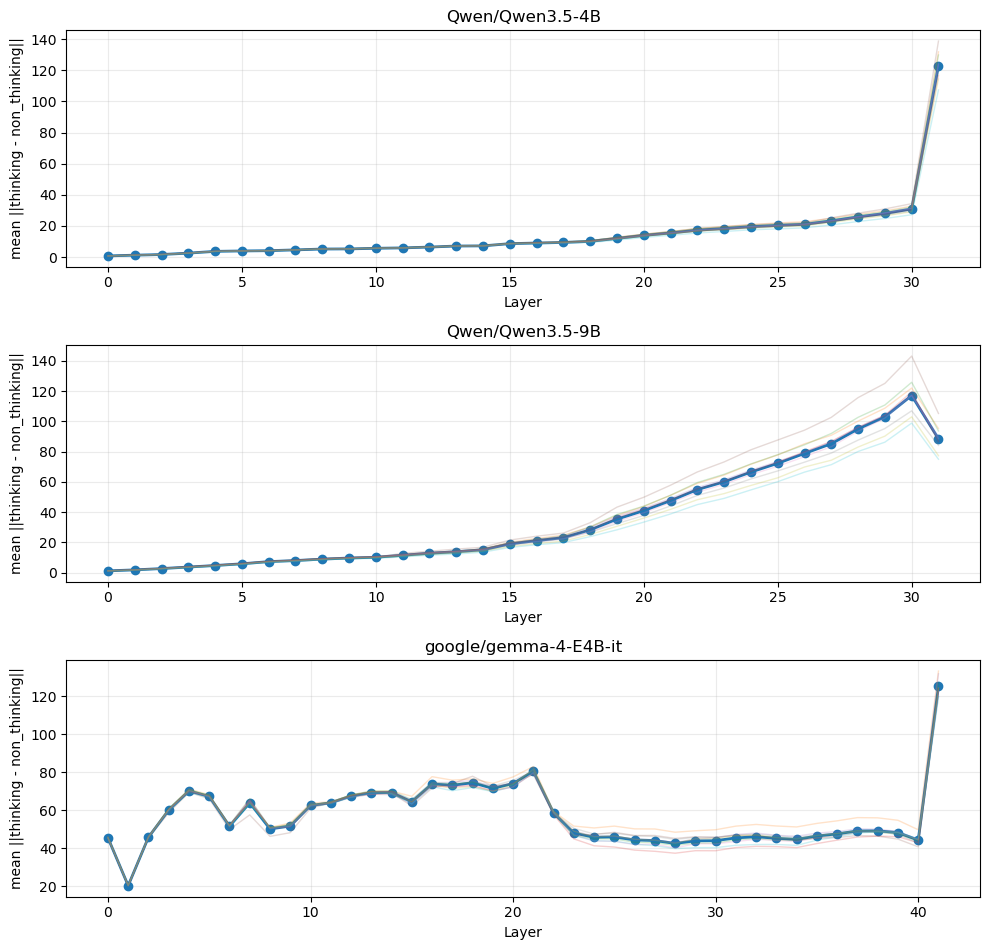

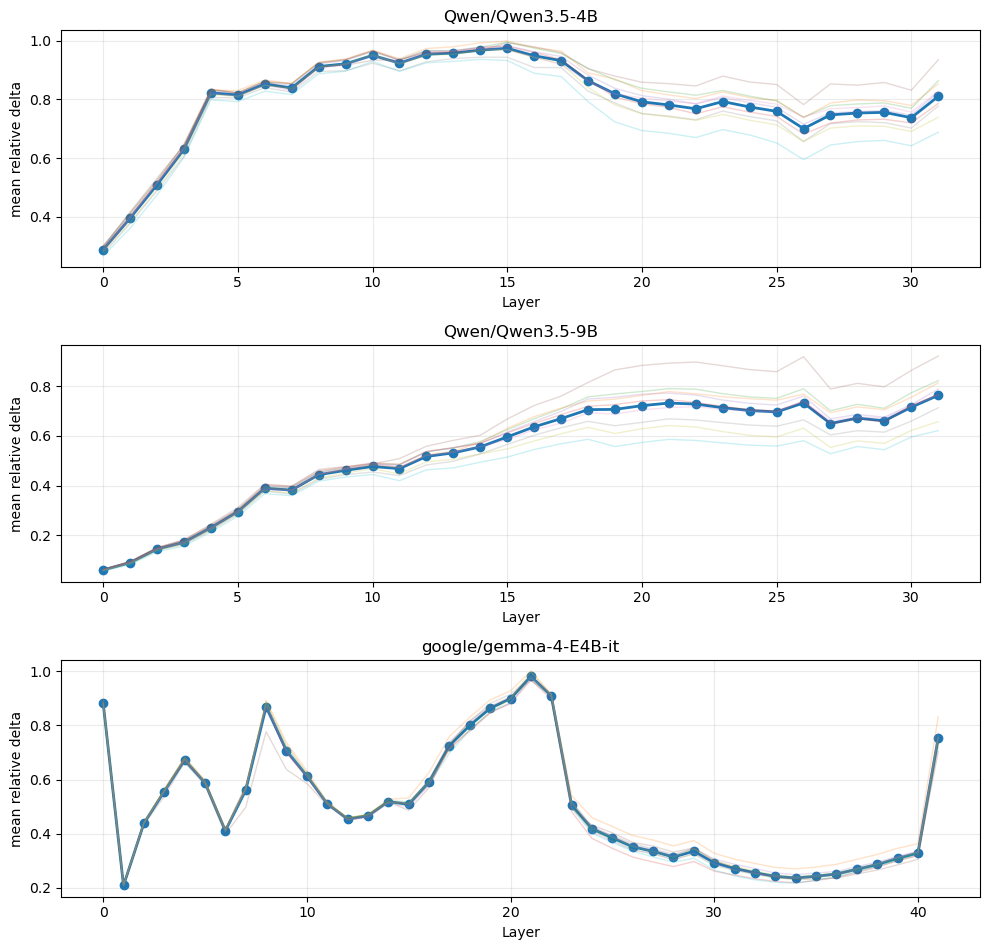

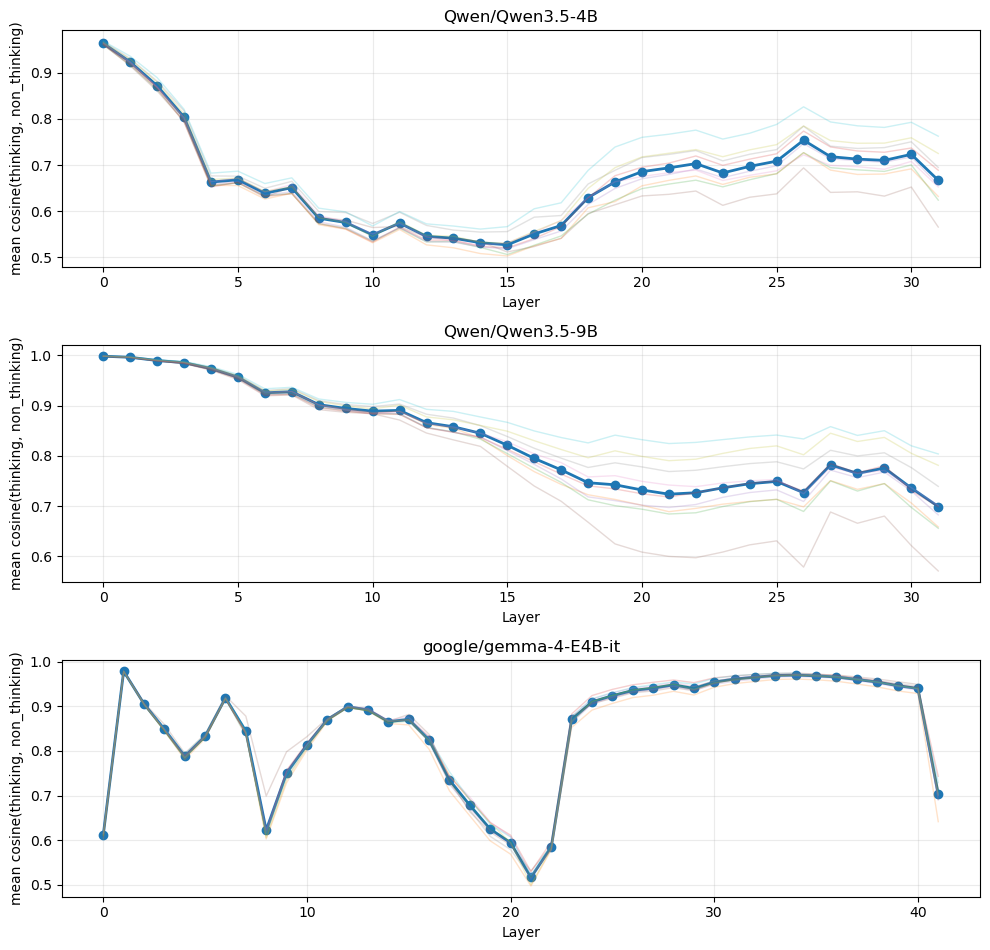

In [6]:
def plot_layer_lines(summary: pd.DataFrame, metric: str, filename: str, ylabel: str):
    if summary.empty:
        print(f"No data for {metric}")
        return
    models = summary["model"].unique()
    fig, axes = plt.subplots(len(models), 1, figsize=(10, 3.2 * len(models)), sharex=False)
    if len(models) == 1:
        axes = [axes]
    for ax, model in zip(axes, models):
        sub = summary[summary["model"] == model]
        overall = sub.groupby("layer")[metric].mean().reset_index()
        ax.plot(overall["layer"], overall[metric], marker="o", linewidth=2, label="all types")
        for ctype, csub in sub.groupby("conflict_type_idx"):
            ax.plot(csub["layer"], csub[metric], alpha=0.22, linewidth=1)
        ax.set_title(model)
        ax.set_xlabel("Layer")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUT_DIR / filename, dpi=180)
    plt.show()

plot_layer_lines(delta_summary, "mean_delta_norm", "01_mean_delta_norm_by_layer.png", "mean ||thinking - non_thinking||")
plot_layer_lines(delta_summary, "mean_relative_delta", "01_mean_relative_delta_by_layer.png", "mean relative delta")
plot_layer_lines(delta_summary, "mean_cos", "01_mean_cos_by_layer.png", "mean cosine(thinking, non_thinking)")


## Experiment 2: Low-rank CoT direction

For each model and selected layer, stack all paired `h_thinking - h_non_thinking` vectors and run PCA. If the top few PCs explain a large fraction of variance, the thinking toggle is activating a shared low-rank direction. If not, the effect is more heterogeneous or type-specific.


In [7]:
def collect_delta_matrix(index: pd.DataFrame, model: str, layer: int, conflict_type_idx: int | None = None) -> tuple[np.ndarray, pd.DataFrame]:
    rows = []
    matrices = []
    subset = index[index["model"] == model]
    if conflict_type_idx is not None:
        subset = subset[subset["conflict_type_idx"] == conflict_type_idx]
    for ctype, group in subset.groupby("conflict_type_idx"):
        piv = group.pivot_table(index="sample_id", columns="thinking_mode", values=["row_idx", "type_dir", "layers"], aggfunc="first")
        if not all(mode in piv["row_idx"].columns for mode in THINKING_MODES):
            continue
        paired = piv.dropna(subset=[("row_idx", "thinking"), ("row_idx", "non_thinking")])
        if paired.empty:
            continue
        if not all(layer in set(x) for x in group["layers"] if isinstance(x, tuple)):
            continue
        ids = paired.index.astype(int).tolist()
        ht = load_layer_matrix(paired[("type_dir", "thinking")].iloc[0], layer, paired[("row_idx", "thinking")].astype(int).to_numpy())
        hn = load_layer_matrix(paired[("type_dir", "non_thinking")].iloc[0], layer, paired[("row_idx", "non_thinking")].astype(int).to_numpy())
        matrices.append(ht - hn)
        rows.extend({"model": model, "conflict_type_idx": int(ctype), "sample_id": int(s)} for s in ids)
    if not matrices:
        return np.empty((0, 0), dtype=np.float32), pd.DataFrame(rows)
    return np.vstack(matrices), pd.DataFrame(rows)


def pca_explained_by_layer(index: pd.DataFrame, max_components: int = 10) -> pd.DataFrame:
    rows = []
    for model in sorted(index["model"].unique()):
        layers = sorted(set().union(*[set(x) for x in index[index["model"] == model]["layers"] if isinstance(x, tuple)]))
        selected_layers = sorted(set([layers[0], layers[len(layers)//4], layers[len(layers)//2], layers[-2], layers[-1]])) if layers else []
        for layer in selected_layers:
            X, meta = collect_delta_matrix(index, model, layer)
            if X.shape[0] < 5:
                continue
            n_components = min(max_components, X.shape[0] - 1, X.shape[1])
            pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
            pca.fit(X - X.mean(axis=0, keepdims=True))
            cum = np.cumsum(pca.explained_variance_ratio_)
            row = {"model": model, "layer": layer, "n": X.shape[0], "dim": X.shape[1]}
            for k in [1, 2, 3, 5, 10]:
                if k <= len(cum):
                    row[f"cum_var_top{k}"] = float(cum[k - 1])
            rows.append(row)
    return pd.DataFrame(rows)

pca_summary = pca_explained_by_layer(hidden_index)
display(pca_summary)
pca_summary.to_csv(OUT_DIR / "02_cot_delta_pca_explained_variance.csv", index=False)


,model,layer,n,dim,cum_var_top1,cum_var_top2,cum_var_top3,cum_var_top5,cum_var_top10
0,Qwen/Qwen3.5-4B,0,861,2560,0.203407,0.279410,0.353405,0.450103,0.585837
1,Qwen/Qwen3.5-4B,8,861,2560,0.182394,0.305846,0.372548,0.470309,0.595714
2,Qwen/Qwen3.5-4B,16,861,2560,0.150750,0.239030,0.312031,0.406365,0.531498
3,Qwen/Qwen3.5-4B,30,861,2560,0.129640,0.219069,0.293017,0.373188,0.482350
4,Qwen/Qwen3.5-4B,31,861,2560,0.120885,0.203827,0.267570,0.339935,0.449902
5,Qwen/Qwen3.5-9B,0,862,4096,0.336002,0.476598,0.592067,0.675960,0.762428
6,Qwen/Qwen3.5-9B,8,862,4096,0.140376,0.249689,0.318570,0.419148,0.548158
7,Qwen/Qwen3.5-9B,16,862,4096,0.121163,0.212095,0.286814,0.385884,0.494818
8,Qwen/Qwen3.5-9B,30,862,4096,0.105553,0.186482,0.259754,0.331373,0.423479
9,Qwen/Qwen3.5-9B,31,862,4096,0.118249,0.187119,0.233892,0.297268,0.400000


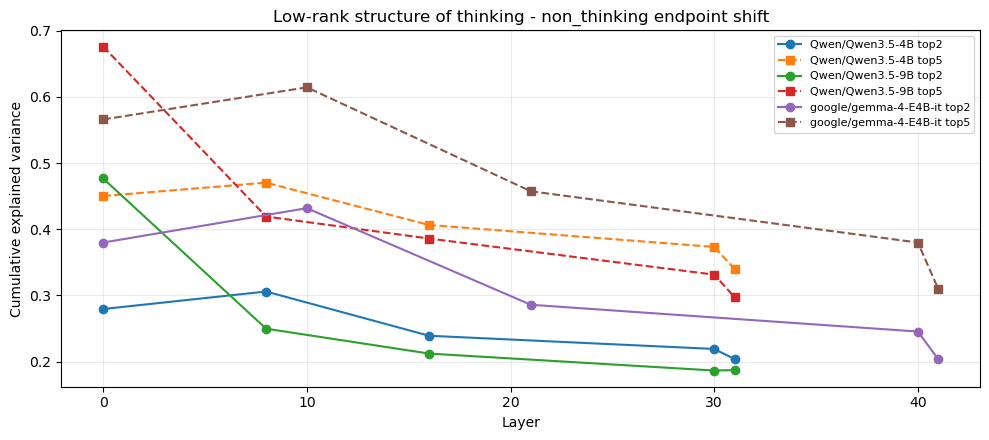

In [8]:
if not pca_summary.empty:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for model, sub in pca_summary.groupby("model"):
        ax.plot(sub["layer"], sub["cum_var_top2"], marker="o", label=f"{model} top2")
        if "cum_var_top5" in sub:
            ax.plot(sub["layer"], sub["cum_var_top5"], marker="s", linestyle="--", label=f"{model} top5")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_title("Low-rank structure of thinking - non_thinking endpoint shift")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "02_cot_delta_pca_explained_variance.png", dpi=180)
    plt.show()


## Experiment 3: Probe separability

This runs a linear probe at each layer. There are two useful targets:

1. `thinking_mode`: a sanity check for whether the representation makes CoT/no-CoT linearly separable.
2. Judged labels: only runs when enough labels are available for a model/mode.

The split is grouped by `(conflict_type_idx, sample_id)` to avoid the same example leaking across train/test.


In [9]:
def build_layer_dataset(index: pd.DataFrame, model: str, layer: int, modes: tuple[str, ...] = THINKING_MODES) -> tuple[np.ndarray, pd.DataFrame]:
    mats = []
    rows = []
    sub = index[(index["model"] == model) & (index["thinking_mode"].isin(modes))]
    for (_, mode, ctype), group in sub.groupby(["model", "thinking_mode", "conflict_type_idx"]):
        if group.empty or layer not in set(group["layers"].iloc[0]):
            continue
        type_dir = group["type_dir"].iloc[0]
        X = load_layer_matrix(type_dir, layer, group["row_idx"].astype(int).to_numpy())
        mats.append(X)
        rows.append(group[["model", "thinking_mode", "conflict_type_idx", "sample_id", "completion_length", "reasoning_chars", "final_answer_chars", "has_reasoning", "has_final_answer"]])
    if not mats:
        return np.empty((0, 0), dtype=np.float32), pd.DataFrame()
    return np.vstack(mats), pd.concat(rows, ignore_index=True)


def grouped_binary_probe(X: np.ndarray, y: np.ndarray, groups: np.ndarray, min_class: int = 10) -> dict:
    values, counts = np.unique(y, return_counts=True)
    if len(values) != 2 or counts.min() < min_class:
        return {"n": len(y), "class_balance": dict(zip(values.tolist(), counts.tolist())), "balanced_accuracy": math.nan, "auc": math.nan}
    n_splits = min(5, counts.min())
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    preds = np.zeros(len(y), dtype=float)
    hard = np.zeros(len(y), dtype=int)
    for train, test in cv.split(X, y, groups=groups):
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        )
        clf.fit(X[train], y[train])
        preds[test] = clf.predict_proba(X[test])[:, 1]
        hard[test] = clf.predict(X[test])
    return {
        "n": int(len(y)),
        "class_balance": dict(zip(values.tolist(), counts.tolist())),
        "balanced_accuracy": float(balanced_accuracy_score(y, hard)),
        "auc": float(roc_auc_score(y, preds)),
    }


def thinking_mode_probe(index: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model in sorted(index["model"].unique()):
        layers = sorted(set().union(*[set(x) for x in index[index["model"] == model]["layers"] if isinstance(x, tuple)]))
        for layer in layers:
            X, meta = build_layer_dataset(index, model, layer)
            if X.shape[0] == 0:
                continue
            y = (meta["thinking_mode"] == "thinking").astype(int).to_numpy()
            groups = (meta["conflict_type_idx"].astype(str) + "_" + meta["sample_id"].astype(str)).to_numpy()
            result = grouped_binary_probe(X, y, groups)
            rows.append({"model": model, "layer": layer, "target": "thinking_mode", **result})
    return pd.DataFrame(rows)

mode_probe = thinking_mode_probe(hidden_index)
display(mode_probe.head())
mode_probe.to_csv(OUT_DIR / "03_probe_thinking_mode_by_layer.csv", index=False)


,model,layer,target,n,class_balance,balanced_accuracy,auc
0,Qwen/Qwen3.5-4B,0,thinking_mode,1725,"{0: 864, 1: 861}",1.0,1.0
1,Qwen/Qwen3.5-4B,1,thinking_mode,1725,"{0: 864, 1: 861}",1.0,1.0
2,Qwen/Qwen3.5-4B,2,thinking_mode,1725,"{0: 864, 1: 861}",1.0,1.0
3,Qwen/Qwen3.5-4B,3,thinking_mode,1725,"{0: 864, 1: 861}",1.0,1.0
4,Qwen/Qwen3.5-4B,4,thinking_mode,1725,"{0: 864, 1: 861}",1.0,1.0


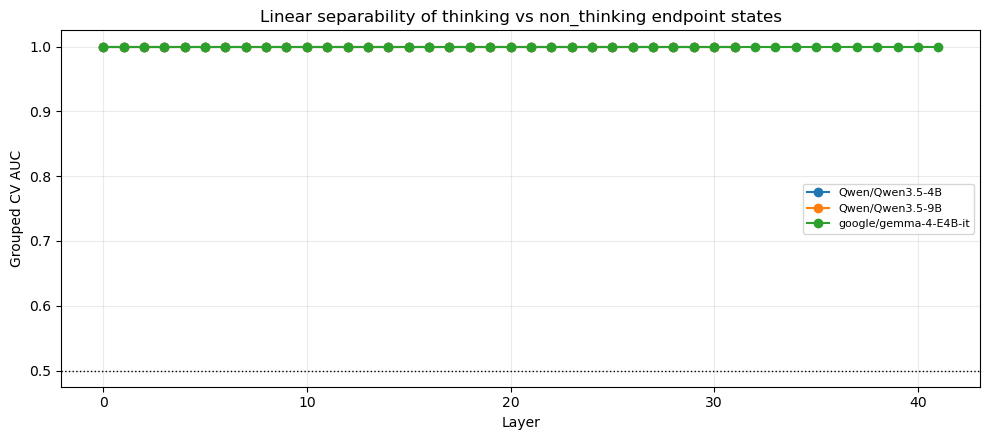

In [10]:
if not mode_probe.empty:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for model, sub in mode_probe.groupby("model"):
        ax.plot(sub["layer"], sub["auc"], marker="o", label=model)
    ax.axhline(0.5, color="black", linewidth=1, linestyle=":")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Grouped CV AUC")
    ax.set_title("Linear separability of thinking vs non_thinking endpoint states")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "03_probe_thinking_mode_auc.png", dpi=180)
    plt.show()


## Experiment 4: Merge judged outcomes and analyze behavior switches

This section is label-dependent. It will run automatically for whatever labels are present. It creates two tables:

- `merged_labels`: one row per hidden-state sample plus all matching labels.
- `mode_pairs`: paired thinking/non-thinking labels for the same model/type/sample.

Useful switch definitions:

- constraint label switch: judged `new/org/neither` changes between modes.
- behavior label switch: behavior category changes between modes.


In [11]:
def choose_eval_labels(eval_labels: pd.DataFrame) -> pd.DataFrame:
    if eval_labels.empty:
        return eval_labels
    # Prefer explicit judge outputs over legacy unknown paths when duplicates exist.
    priority = eval_labels["judge_model"].map(lambda x: 0 if x != "unknown_or_legacy" else 1)
    labels = eval_labels.assign(_priority=priority)
    labels = labels.sort_values(["label_kind", "model", "thinking_mode", "conflict_type_idx", "sample_id", "_priority"])
    labels = labels.drop_duplicates(["label_kind", "model", "thinking_mode", "conflict_type_idx", "sample_id"], keep="first")
    return labels.drop(columns=["_priority"])

chosen_labels = choose_eval_labels(eval_labels)
label_wide = pd.DataFrame()
if not chosen_labels.empty:
    label_wide = chosen_labels.pivot_table(
        index=["model", "thinking_mode", "conflict_type_idx", "sample_id"],
        columns="label_kind",
        values=["label", "label_name", "judge_model"],
        aggfunc="first",
    )
    label_wide.columns = [f"{kind}_{field}" for field, kind in label_wide.columns]
    label_wide = label_wide.reset_index()

merged_labels = hidden_index.merge(label_wide, on=["model", "thinking_mode", "conflict_type_idx", "sample_id"], how="left") if not label_wide.empty else hidden_index.copy()
display(merged_labels.head())
merged_labels.to_csv(OUT_DIR / "04_hidden_index_with_labels.csv", index=False)

if not chosen_labels.empty:
    display(chosen_labels.groupby(["label_kind", "model", "thinking_mode", "label_name"]).size().reset_index(name="n").head(80))


,model,model_dir,thinking_mode,enable_thinking,condition,conflict_type_idx,sample_id,row_idx,type_dir,layers,n_layers,prefix_length,response_path,task,conflict_type,finish_reason,stop_reason,prompt_length,completion_length,reasoning_chars,final_answer_chars,response_chars,has_reasoning,has_final_answer,behavior_judge_model,constraint_judge_model,behavior_label,constraint_label,behavior_label_name,constraint_label_name
0,Qwen/Qwen3.5-4B,/Users/xinmingwang/Library/CloudStorage/OneDri...,non_thinking,False,conflict,1,1,0,/Users/xinmingwang/Library/CloudStorage/OneDri...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32,66,/Users/xinmingwang/Library/CloudStorage/OneDri...,email writting,Conflicts between Content Constraints,stop,NaN,67,237,0,1155,1155,False,True,NaN,gpt-4o-2024-11-20,NaN,2.0,NaN,org_constraint
1,Qwen/Qwen3.5-4B,/Users/xinmingwang/Library/CloudStorage/OneDri...,non_thinking,False,conflict,1,2,1,/Users/xinmingwang/Library/CloudStorage/OneDri...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32,76,/Users/xinmingwang/Library/CloudStorage/OneDri...,email writting,Conflicts between Content Constraints,stop,NaN,77,191,0,948,948,False,True,NaN,gpt-4o-2024-11-20,NaN,-1.0,NaN,neither
2,Qwen/Qwen3.5-4B,/Users/xinmingwang/Library/CloudStorage/OneDri...,non_thinking,False,conflict,1,3,2,/Users/xinmingwang/Library/CloudStorage/OneDri...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32,65,/Users/xinmingwang/Library/CloudStorage/OneDri...,email writting,Conflicts between Content Constraints,stop,NaN,66,128,0,628,628,False,True,NaN,gpt-4o-2024-11-20,NaN,1.0,NaN,new_constraint
3,Qwen/Qwen3.5-4B,/Users/xinmingwang/Library/CloudStorage/OneDri...,non_thinking,False,conflict,1,4,3,/Users/xinmingwang/Library/CloudStorage/OneDri...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32,69,/Users/xinmingwang/Library/CloudStorage/OneDri...,email writting,Conflicts between Content Constraints,stop,NaN,70,185,0,1006,1006,False,True,NaN,gpt-4o-2024-11-20,NaN,2.0,NaN,org_constraint
4,Qwen/Qwen3.5-4B,/Users/xinmingwang/Library/CloudStorage/OneDri...,non_thinking,False,conflict,1,5,4,/Users/xinmingwang/Library/CloudStorage/OneDri...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32,54,/Users/xinmingwang/Library/CloudStorage/OneDri...,email writting,Conflicts between Content Constraints,stop,NaN,55,147,0,721,721,False,True,NaN,gpt-4o-2024-11-20,NaN,1.0,NaN,new_constraint


,label_kind,model,thinking_mode,label_name,n
0,behavior,google/gemma-4-12B-it,non_thinking,asks_for_clarification_without_answering,27
1,behavior,google/gemma-4-12B-it,non_thinking,direct_answer_without_acknowledging_conflict,775
2,behavior,google/gemma-4-12B-it,non_thinking,other,12
3,behavior,google/gemma-4-12B-it,non_thinking,self_resolves_conflict_and_answers,50
4,behavior,google/gemma-4-12B-it,thinking,asks_for_clarification_without_answering,10
5,behavior,google/gemma-4-12B-it,thinking,direct_answer_without_acknowledging_conflict,191
6,behavior,google/gemma-4-12B-it,thinking,other,2
7,behavior,google/gemma-4-12B-it,thinking,parse_failed,364
8,behavior,google/gemma-4-12B-it,thinking,self_resolves_conflict_and_answers,10
9,behavior,google/gemma-4-E4B-it,non_thinking,asks_for_clarification_without_answering,11


In [12]:
def make_mode_pairs(label_wide: pd.DataFrame) -> pd.DataFrame:
    if label_wide.empty:
        return pd.DataFrame()
    rows = []
    base_cols = ["model", "conflict_type_idx", "sample_id"]
    for (model, ctype, sample_id), group in label_wide.groupby(base_cols):
        if set(group["thinking_mode"]) >= set(THINKING_MODES):
            n = group[group["thinking_mode"] == "non_thinking"].iloc[0]
            t = group[group["thinking_mode"] == "thinking"].iloc[0]
            row = {"model": model, "conflict_type_idx": ctype, "sample_id": sample_id}
            for prefix, item in [("non_thinking", n), ("thinking", t)]:
                for col in group.columns:
                    if col not in ["model", "thinking_mode", "conflict_type_idx", "sample_id"]:
                        row[f"{prefix}_{col}"] = item.get(col)
            for kind in ["constraint", "behavior"]:
                a = row.get(f"non_thinking_{kind}_label_name")
                b = row.get(f"thinking_{kind}_label_name")
                row[f"{kind}_switched"] = pd.notna(a) and pd.notna(b) and a != b
            rows.append(row)
    return pd.DataFrame(rows)

mode_pairs = make_mode_pairs(label_wide)
display(mode_pairs.head())
if not mode_pairs.empty:
    display(mode_pairs[["model", "constraint_switched", "behavior_switched"]].groupby("model").mean(numeric_only=True).reset_index())
    mode_pairs.to_csv(OUT_DIR / "04_mode_label_pairs.csv", index=False)
else:
    print("No paired thinking/non_thinking label table available yet.")


,model,conflict_type_idx,sample_id,non_thinking_behavior_judge_model,non_thinking_constraint_judge_model,non_thinking_behavior_label,non_thinking_constraint_label,non_thinking_behavior_label_name,non_thinking_constraint_label_name,thinking_behavior_judge_model,thinking_constraint_judge_model,thinking_behavior_label,thinking_constraint_label,thinking_behavior_label_name,thinking_constraint_label_name,constraint_switched,behavior_switched
0,Qwen/Qwen3.5-4B,1,1,NaN,gpt-4o-2024-11-20,NaN,2.0,NaN,org_constraint,NaN,gpt-4o-2024-11-20,NaN,-1.0,NaN,neither,True,False
1,Qwen/Qwen3.5-4B,1,2,NaN,gpt-4o-2024-11-20,NaN,-1.0,NaN,neither,NaN,gpt-4o-2024-11-20,NaN,-1.0,NaN,neither,False,False
2,Qwen/Qwen3.5-4B,1,3,NaN,gpt-4o-2024-11-20,NaN,1.0,NaN,new_constraint,NaN,gpt-4o-2024-11-20,NaN,1.0,NaN,new_constraint,False,False
3,Qwen/Qwen3.5-4B,1,4,NaN,gpt-4o-2024-11-20,NaN,2.0,NaN,org_constraint,NaN,gpt-4o-2024-11-20,NaN,-1.0,NaN,neither,True,False
4,Qwen/Qwen3.5-4B,1,5,NaN,gpt-4o-2024-11-20,NaN,1.0,NaN,new_constraint,NaN,gpt-4o-2024-11-20,NaN,-1.0,NaN,neither,True,False


,model,constraint_switched,behavior_switched
0,Qwen/Qwen3.5-4B,0.613119,0.000000
1,google/gemma-4-12B-it,0.000000,0.665511
2,google/gemma-4-E4B-it,0.405093,0.128472


,model,layer,switch_col,n_switched,n_same,mean_delta_switched,mean_delta_same,median_delta_switched,median_delta_same,mannwhitney_p
0,Qwen/Qwen3.5-4B,0,constraint_switched,457,287,0.716020,0.712171,0.720821,0.716555,0.209506
1,Qwen/Qwen3.5-4B,1,constraint_switched,457,287,1.199564,1.185204,1.201307,1.197001,0.021872
2,Qwen/Qwen3.5-4B,2,constraint_switched,457,287,1.613825,1.599036,1.620952,1.612610,0.023241
3,Qwen/Qwen3.5-4B,3,constraint_switched,457,287,2.521189,2.502397,2.527051,2.524212,0.071662
4,Qwen/Qwen3.5-4B,4,constraint_switched,457,287,3.648489,3.635010,3.655049,3.642504,0.210653


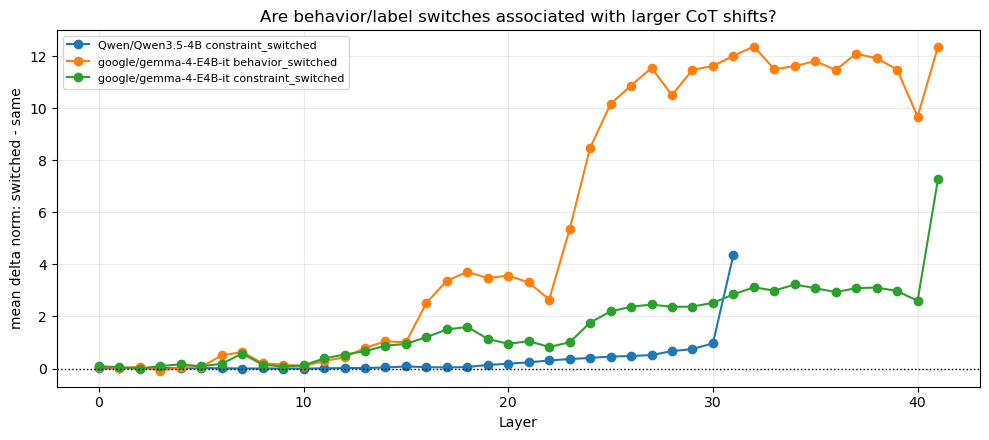

In [13]:
def switch_delta_analysis(delta_samples: pd.DataFrame, mode_pairs: pd.DataFrame, switch_col: str) -> pd.DataFrame:
    if delta_samples.empty or mode_pairs.empty or switch_col not in mode_pairs:
        return pd.DataFrame()
    rows = []
    joined = delta_samples.merge(
        mode_pairs[["model", "conflict_type_idx", "sample_id", switch_col]],
        on=["model", "conflict_type_idx", "sample_id"],
        how="inner",
    ).dropna(subset=[switch_col])
    for (model, layer), sub in joined.groupby(["model", "layer"]):
        a = sub[sub[switch_col] == True]["delta_norm"].to_numpy()
        b = sub[sub[switch_col] == False]["delta_norm"].to_numpy()
        if len(a) < 3 or len(b) < 3:
            continue
        stat = mannwhitneyu(a, b, alternative="two-sided")
        rows.append({
            "model": model,
            "layer": layer,
            "switch_col": switch_col,
            "n_switched": len(a),
            "n_same": len(b),
            "mean_delta_switched": float(np.mean(a)),
            "mean_delta_same": float(np.mean(b)),
            "median_delta_switched": float(np.median(a)),
            "median_delta_same": float(np.median(b)),
            "mannwhitney_p": float(stat.pvalue),
        })
    return pd.DataFrame(rows)

switch_results = pd.concat([
    switch_delta_analysis(delta_samples, mode_pairs, "constraint_switched"),
    switch_delta_analysis(delta_samples, mode_pairs, "behavior_switched"),
], ignore_index=True)
display(switch_results.head())
switch_results.to_csv(OUT_DIR / "04_switch_delta_norm_tests.csv", index=False)

if not switch_results.empty:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for (model, switch_col), sub in switch_results.groupby(["model", "switch_col"]):
        diff = sub["mean_delta_switched"] - sub["mean_delta_same"]
        ax.plot(sub["layer"], diff, marker="o", label=f"{model} {switch_col}")
    ax.axhline(0, color="black", linewidth=1, linestyle=":")
    ax.set_xlabel("Layer")
    ax.set_ylabel("mean delta norm: switched - same")
    ax.set_title("Are behavior/label switches associated with larger CoT shifts?")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "04_switch_delta_norm_difference.png", dpi=180)
    plt.show()
else:
    print("Switch analysis skipped because paired labels are missing or insufficient.")


## Experiment 5: Outcome probes

For each available binary outcome, train a linear probe from endpoint hidden states. This is more interpretable than predicting the multi-class label directly when sample counts are small.

The targets are created only when labels exist:

- `is_new`, `is_org`, `is_neither` from constraint labels.
- `is_direct_no_ack`, `is_asks_clarification`, `is_self_resolves`, `is_other`, `is_parse_failed` from behavior labels.


In [14]:
def add_binary_targets(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if "constraint_label_name" in out:
        for name in ["new", "org", "neither", "neither_or_parse_failed"]:
            out[f"is_constraint_{name}"] = (out["constraint_label_name"] == name).astype(float)
    if "behavior_label_name" in out:
        for name in ["direct_no_ack", "asks_clarification", "self_resolves", "other", "parse_failed"]:
            out[f"is_behavior_{name}"] = (out["behavior_label_name"] == name).astype(float)
    return out

labeled_index = add_binary_targets(merged_labels)
TARGET_COLS = [c for c in labeled_index.columns if c.startswith("is_constraint_") or c.startswith("is_behavior_")]
print(TARGET_COLS)


['is_constraint_new', 'is_constraint_org', 'is_constraint_neither', 'is_constraint_neither_or_parse_failed', 'is_behavior_direct_no_ack', 'is_behavior_asks_clarification', 'is_behavior_self_resolves', 'is_behavior_other', 'is_behavior_parse_failed']


In [15]:
def outcome_probe(index: pd.DataFrame, target_cols: list[str]) -> pd.DataFrame:
    rows = []
    for model in sorted(index["model"].unique()):
        layers = sorted(set().union(*[set(x) for x in index[index["model"] == model]["layers"] if isinstance(x, tuple)]))
        for mode in THINKING_MODES:
            for layer in layers:
                X, meta = build_layer_dataset(index, model, layer, modes=(mode,))
                if X.shape[0] == 0:
                    continue
                # Re-merge labels because build_layer_dataset returns a compact metadata subset.
                meta = meta.merge(
                    index[["model", "thinking_mode", "conflict_type_idx", "sample_id"] + target_cols],
                    on=["model", "thinking_mode", "conflict_type_idx", "sample_id"],
                    how="left",
                )
                groups = (meta["conflict_type_idx"].astype(str) + "_" + meta["sample_id"].astype(str)).to_numpy()
                for target in target_cols:
                    valid = meta[target].notna()
                    y = meta.loc[valid, target].astype(int).to_numpy()
                    if len(y) != valid.sum():
                        continue
                    result = grouped_binary_probe(X[valid.to_numpy()], y, groups[valid.to_numpy()], min_class=8)
                    rows.append({"model": model, "thinking_mode": mode, "layer": layer, "target": target, **result})
    return pd.DataFrame(rows)

outcome_probe_results = outcome_probe(labeled_index, TARGET_COLS) if TARGET_COLS else pd.DataFrame()
display(outcome_probe_results.head())
outcome_probe_results.to_csv(OUT_DIR / "05_outcome_probe_by_layer.csv", index=False)


KeyboardInterrupt: 

In [ ]:
if not outcome_probe_results.empty:
    best = (
        outcome_probe_results.dropna(subset=["auc"])
        .sort_values("auc", ascending=False)
        .groupby(["model", "thinking_mode", "target"])
        .head(1)
        .sort_values(["model", "thinking_mode", "target"])
    )
    display(best[["model", "thinking_mode", "target", "layer", "n", "balanced_accuracy", "auc"]])
    best.to_csv(OUT_DIR / "05_best_outcome_probe_layers.csv", index=False)
else:
    print("Outcome probes skipped because no usable labels were found.")


## Experiment 6: Length and parsing controls

CoT hidden-state differences can be confounded by response length or missing final answers. This section correlates layer-wise CoT delta with length changes between modes.


In [16]:
def length_pair_table(index: pd.DataFrame) -> pd.DataFrame:
    rows = []
    keep = ["completion_length", "reasoning_chars", "final_answer_chars", "response_chars", "has_reasoning", "has_final_answer"]
    for (model, ctype, sample_id), group in index.groupby(["model", "conflict_type_idx", "sample_id"]):
        if set(group["thinking_mode"]) >= set(THINKING_MODES):
            n = group[group["thinking_mode"] == "non_thinking"].iloc[0]
            t = group[group["thinking_mode"] == "thinking"].iloc[0]
            row = {"model": model, "conflict_type_idx": ctype, "sample_id": sample_id}
            for col in keep:
                row[f"thinking_{col}"] = t.get(col)
                row[f"non_thinking_{col}"] = n.get(col)
                if pd.api.types.is_numeric_dtype(pd.Series([t.get(col), n.get(col)])):
                    row[f"delta_{col}"] = t.get(col) - n.get(col)
            rows.append(row)
    return pd.DataFrame(rows)

length_pairs = length_pair_table(hidden_index)
length_joined = delta_samples.merge(length_pairs, on=["model", "conflict_type_idx", "sample_id"], how="left")
length_pairs.to_csv(OUT_DIR / "06_length_mode_pairs.csv", index=False)

def corr_by_layer(frame: pd.DataFrame, x_col: str, y_col: str = "delta_norm") -> pd.DataFrame:
    rows = []
    if x_col not in frame:
        return pd.DataFrame()
    for (model, layer), sub in frame.dropna(subset=[x_col, y_col]).groupby(["model", "layer"]):
        if len(sub) < 10 or sub[x_col].nunique() < 3:
            continue
        sp = spearmanr(sub[x_col], sub[y_col])
        rows.append({"model": model, "layer": layer, "x": x_col, "n": len(sub), "spearman_r": float(sp.correlation), "p": float(sp.pvalue)})
    return pd.DataFrame(rows)

length_corrs = pd.concat([
    corr_by_layer(length_joined, "delta_completion_length"),
    corr_by_layer(length_joined, "delta_reasoning_chars"),
    corr_by_layer(length_joined, "delta_final_answer_chars"),
    corr_by_layer(length_joined, "delta_response_chars"),
], ignore_index=True)
display(length_corrs.head())
length_corrs.to_csv(OUT_DIR / "06_length_delta_correlations.csv", index=False)


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

In [ ]:
if not length_corrs.empty:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for (model, x), sub in length_corrs.groupby(["model", "x"]):
        ax.plot(sub["layer"], sub["spearman_r"], marker="o", label=f"{model} {x}")
    ax.axhline(0, color="black", linewidth=1, linestyle=":")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Spearman r with delta_norm")
    ax.set_title("Length controls for CoT hidden-state shift magnitude")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "06_length_delta_correlations.png", dpi=180)
    plt.show()
else:
    print("No length correlations available.")


## Experiment 7: Type-specific CoT directions

This measures whether each conflict type has the same CoT direction. For a selected layer, compute the mean normalized `thinking - non_thinking` direction for each type, then measure pairwise cosine similarity.

High off-diagonal cosine means a shared CoT direction; low or negative values mean type-specific shifts.


In [17]:
def type_direction_cosines(index: pd.DataFrame, layer_selector: str = "middle") -> pd.DataFrame:
    rows = []
    for model in sorted(index["model"].unique()):
        layers = sorted(set().union(*[set(x) for x in index[index["model"] == model]["layers"] if isinstance(x, tuple)]))
        if not layers:
            continue
        if layer_selector == "middle":
            layer = layers[len(layers) // 2]
        elif layer_selector == "late":
            layer = layers[-2]
        else:
            layer = int(layer_selector)
        dirs = {}
        for ctype in sorted(index[index["model"] == model]["conflict_type_idx"].unique()):
            X, meta = collect_delta_matrix(index, model, layer, int(ctype))
            if X.shape[0] < 3:
                continue
            direction = X.mean(axis=0)
            direction = direction / max(np.linalg.norm(direction), 1e-12)
            dirs[int(ctype)] = direction
        for a, da in dirs.items():
            for b, db in dirs.items():
                rows.append({"model": model, "layer": layer, "type_a": a, "type_b": b, "cosine": float(np.dot(da, db))})
    return pd.DataFrame(rows)

type_cos = type_direction_cosines(hidden_index, "middle")
display(type_cos.head())
type_cos.to_csv(OUT_DIR / "07_type_direction_cosines_middle_layer.csv", index=False)


,model,layer,type_a,type_b,cosine
0,Qwen/Qwen3.5-4B,16,1,1,1.000000
1,Qwen/Qwen3.5-4B,16,1,2,0.935863
2,Qwen/Qwen3.5-4B,16,1,3,0.907618
3,Qwen/Qwen3.5-4B,16,1,4,0.939301
4,Qwen/Qwen3.5-4B,16,1,5,0.781879


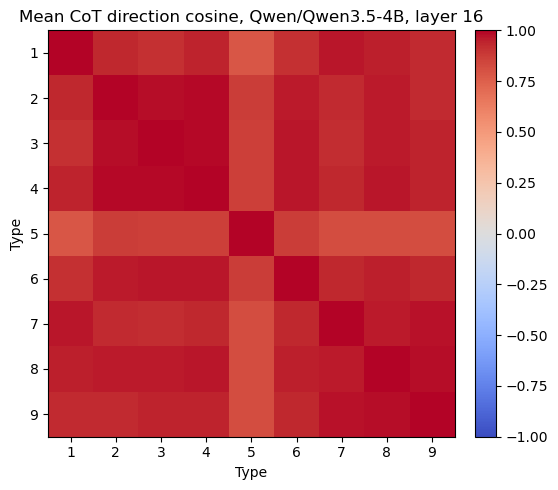

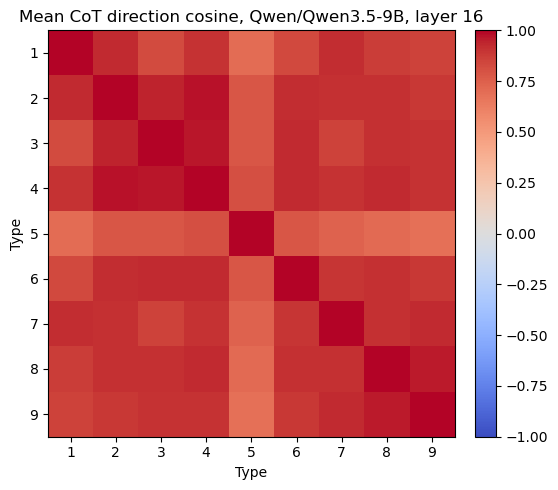

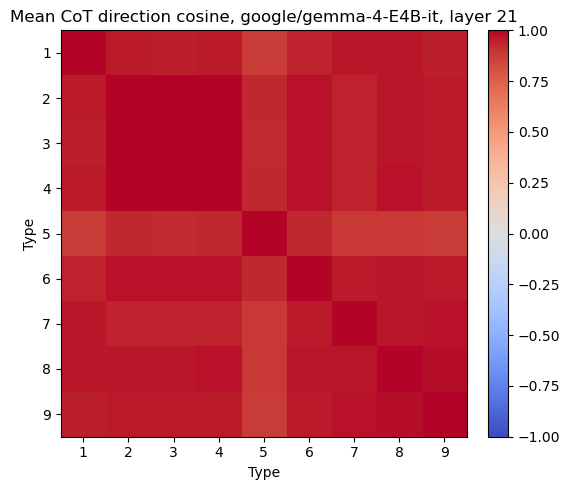

In [18]:
if not type_cos.empty:
    for model, sub in type_cos.groupby("model"):
        mat = sub.pivot(index="type_a", columns="type_b", values="cosine").sort_index().sort_index(axis=1)
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(mat.values, vmin=-1, vmax=1, cmap="coolwarm")
        ax.set_xticks(range(len(mat.columns)))
        ax.set_xticklabels(mat.columns)
        ax.set_yticks(range(len(mat.index)))
        ax.set_yticklabels(mat.index)
        ax.set_xlabel("Type")
        ax.set_ylabel("Type")
        ax.set_title(f"Mean CoT direction cosine, {model}, layer {sub['layer'].iloc[0]}")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"07_type_direction_cosines__{safe_model_name(model)}.png", dpi=180)
        plt.show()


## Quick interpretation checklist

Use this checklist after running the notebook:

1. If `thinking_mode` probe AUC is near 1.0 but outcome probe AUC is weak, CoT mode is represented but not aligned with the behavior labels.
2. If CoT delta norm peaks in late layers, the endpoint representation shift is likely generated-answer dependent; compare with prompt-only hidden states before claiming pre-generation mode activation.
3. If top-2/top-5 PCA variance is high, a low-rank CoT steering direction is plausible.
4. If switched samples have larger CoT deltas than unchanged samples, the hidden-state shift is behavior-relevant.
5. If delta norm strongly tracks completion/reasoning length, report length-controlled results before making mechanistic claims.


In [19]:
print("<|channel>thought\nThinking Process:\n\n1.  **Analyze the Request:** The user wants an email to their boss announcing their resignation.\n2.  **Analyze the Constraints/Requirements:**\n    *   Must announce the resignation.\n    *   Must include specific reasons for leaving (e.g., career growth, personal circumstances).\n    *   **Crucial Constraint:** *Do not* include any reasons for the resignation in the email. (This is a contradiction.)\n\n3.  **Identify the Contradiction:** The user asks the email *to include* specific reasons, but immediately follows up by saying *not to include* any reasons.\n\n4.  **Determine the Appropriate Action:** The instruction \"Do not include any reasons\" overrides the instruction \"The email must include specific reasons.\" When conflicting instructions are given, the negative constraint (Do Not Include) is usually the stronger directive to follow, as it dictates what the final output *must avoid*.\n\n5.  **Drafting Strategy (Focusing on Professionalism and Ambiguity):** The resignation email must be professional, appreciative, clear about the departure date, and provide an acceptable, yet vague, reason that satisfies the \"specific reason\" requirement without revealing true details.\n\n6.  **Structuring the Email:**\n    *   Subject Line (Clear and Professional).\n    *   Greeting (Formal).\n    *   The Announcement (Clear statement of resignation and final date).\n    *   The Reason (Professional, high-level justification that does not elaborate).\n    *   Transition/Offer of Help (Commitment to smooth transition).\n    *   Closing (Gratitude and farewell).\n\n7.  **Refining the Language (Self-Correction during drafting):** Instead of saying \"I'm leaving for growth,\" I should say, \"I have accepted an opportunity that aligns more closely with my long-term career objectives.\" This satisfies the *intent* of providing a reason (growth/new direction) while avoiding the *specific details* (e.g., \"I'm going to Google,\" or \"I need more salary\").\n\n8.  **Final Polish and Output Generation.** (This leads to the suggested email options.)<channel|>Since you have given two contradictory instructions—telling me to include specific reasons, but also telling me *not* to include any reasons—I will prioritize the instruction to **not include any reasons**.\n\nTo fulfill this while still providing a professional and necessary justification (as often required when resigning), I will use highly professional, general language that indicates a change in direction without revealing specific circumstances or company names.\n\nHere are two options, depending on whether you want to lean toward a \"Career Growth\" reason or \"Personal Circumstances.\"\n\n***\n\n### Option 1: Leaning toward Career Growth/New Opportunity (Most common professional choice)\n\n**Subject:** Resignation - [Your Name]\n\nDear [Boss's Name],\n\nPlease accept this email as formal notification that I am resigning from my position as [Your Job Title] at [Company Name]. My final day of employment will be [Your Last Day – usually two weeks from the date of the email].\n\nThis was not an easy decision, as I genuinely value the time I have spent at [Company Name]. However, I have accepted an opportunity that allows me to pursue a specific direction in my career that I feel is the right next step for my long-term professional development.\n\nI am committed to ensuring a smooth transition during my remaining two weeks. I am happy to complete my current projects and assist in training my replacement in any way possible.\n\nThank you for the guidance and opportunities you have given me during my time here. I wish you and the team all the best for the future.\n\nSincerely,\n\n[Your Name]\n\n***\n\n### Option 2: Leaning toward Personal Circumstances (When you prefer more privacy)\n\n**Subject:** Resignation - [Your Name]\n\nDear [Boss's Name],\n\nPlease accept this email as formal notification that I am resigning from my position as [Your Job Title] at [Company Name]. My final day of employment will be [Your Last Day – usually two weeks from the date of the email].\n\nThis decision comes as I need to step away to focus on some personal circumstances that require my full attention at this time.\n\nI deeply appreciate the opportunities and support you have provided me over the past [Number] years/months. I am committed to making this transition as seamless as possible and will work diligently over the next two weeks to document my projects and assist with the handover process.\n\nThank you again for everything. I wish the company continued success.\n\nSincerely,\n\n[Your Name]<turn|>")

<|channel>thought
Thinking Process:

1.  **Analyze the Request:** The user wants an email to their boss announcing their resignation.
2.  **Analyze the Constraints/Requirements:**
    *   Must announce the resignation.
    *   Must include specific reasons for leaving (e.g., career growth, personal circumstances).
    *   **Crucial Constraint:** *Do not* include any reasons for the resignation in the email. (This is a contradiction.)

3.  **Identify the Contradiction:** The user asks the email *to include* specific reasons, but immediately follows up by saying *not to include* any reasons.

4.  **Determine the Appropriate Action:** The instruction "Do not include any reasons" overrides the instruction "The email must include specific reasons." When conflicting instructions are given, the negative constraint (Do Not Include) is usually the stronger directive to follow, as it dictates what the final output *must avoid*.

5.  **Drafting Strategy (Focusing on Professionalism and Ambiguity)

In [20]:
print("<|channel>thought\nHere's a thinking process that leads to the suggested email:\n\n1.  **Analyze the Request:**\n    *   **Goal:** Write a professional email to a boss asking for a raise.\n    *   **Mandatory Content:** Must include at least three justifications (e.g., recent achievements, increased responsibilities, market comparisons).\n    *   **Crucial Constraint:** *Do not* state the specific reasons for the raise (e.g., \"I need more money,\" \"Cost of living\"). The email must be focused on *value* delivered, not personal need.\n\n2.  **Determine the Tone and Structure (Professionalism Check):**\n    *   **Tone:** Confident, appreciative, respectful, proactive, and professional. *Never* entitled or aggressive.\n    *   **Structure:**\n        *   Subject Line (Clear and professional).\n        *   Greeting (Formal).\n        *   Opening (State the purpose respectfully, requesting a meeting).\n        *   The Pitch/Justification (Present the evidence of value).\n        *   The Ask (Reiterate the request for a compensation review/raise discussion).\n        *   Closing (Thank the boss, suggest next steps).\n\n3.  **Develop the Justifications (The \"Meat\" of the Email):**\n    *   *Need 3 Strong Points.*\n    *   *Point 1: Achievements/Impact (Quantifiable success).* Example: Exceeded targets, completed a major project early.\n    *   *Point 2: Increased Scope/Responsibilities (Growth within the role).* Example: Taking on team leadership, managing a new client vertical, handling complex projects previously done by others.\n    *   *Point 3: Market Value/Skill Depth (External validation or specialized skill).* Example: Mastering a new crucial software/skill set, or performance alignment with industry standards for the role.\n\n4.  **Drafting - Focusing on the Constraint:**\n    *   *Self-Correction Check:* Ensure I don't write phrases like \"I deserve a raise because...\" Instead, I should write, \"Given my contributions, I would like to discuss adjusting my compensation.\"\n    *   *Focus:* Frame the discussion around the *alignment* between the current scope of work/value delivered and the current compensation.\n\n5.  **Review and Refine (Polishing the language):**\n    *   *Subject:* Needs to signal importance without being demanding.\n    *   *Body:* Ensure the language is growth-oriented (\"looking forward,\" \"contribute further,\" \"alignment\").\n\n6.  **Final Polish (The result provided below).** (This matches the prompt's requirements perfectly: Professional, asks for a raise discussion, includes 3 justifications without stating the personal reason for the raise.)<channel|>**Subject: Compensation Review and Career Growth Discussion**\n\nDear [Boss's Name],\n\nI hope this email finds you well.\n\nI am writing to formally request a meeting to discuss my current role and compensation. Over the past [Duration, e.g., year/18 months], I have been highly engaged in my work at [Company Name] and am extremely proud of the value I have consistently brought to the team. I believe my current contributions and growth warrant a discussion regarding an adjustment to my salary and compensation structure.\n\nI have compiled several key areas of impact that demonstrate how my role has expanded and how my performance has exceeded expectations. Specifically, I would like to highlight:\n\n1.  **Increased Scope and Responsibility:** Since [Date/Event], I have taken the lead on [Specific project or function, e.g., managing the international client portfolio], which involves a level of strategic oversight and decision-making that extends beyond the original parameters of my job description.\n2.  **Measurable Achievements:** I successfully spearheaded the [Name of Project], which resulted in a [Specific, quantifiable result, e.g., 15% increase in efficiency/reduction in operating costs]. This achievement significantly contributed to [Company Goal].\n3.  **Mastery of Advanced Skills:** I have dedicated significant time to mastering [Specific, in-demand skill or software, e.g., advanced data modeling/Agile project management], enabling me to solve increasingly complex problems and streamline workflows for the entire department.\n\nI am incredibly committed to [Company Name]'s success and am excited about the opportunities to contribute even more in the future. I would appreciate the opportunity to schedule a dedicated time next week to discuss how my current role and market value align with my responsibilities and compensation.\n\nPlease let me know what time works best for you.\n\nThank you for your time and consideration.\n\nBest regards,\n\n[Your Name]<turn|>")

<|channel>thought
Here's a thinking process that leads to the suggested email:

1.  **Analyze the Request:**
    *   **Goal:** Write a professional email to a boss asking for a raise.
    *   **Mandatory Content:** Must include at least three justifications (e.g., recent achievements, increased responsibilities, market comparisons).
    *   **Crucial Constraint:** *Do not* state the specific reasons for the raise (e.g., "I need more money," "Cost of living"). The email must be focused on *value* delivered, not personal need.

2.  **Determine the Tone and Structure (Professionalism Check):**
    *   **Tone:** Confident, appreciative, respectful, proactive, and professional. *Never* entitled or aggressive.
    *   **Structure:**
        *   Subject Line (Clear and professional).
        *   Greeting (Formal).
        *   Opening (State the purpose respectfully, requesting a meeting).
        *   The Pitch/Justification (Present the evidence of value).
        *   The Ask (Reiterate the r

In [2]:
print("<|channel>thought\nHere's a thinking process to arrive at the suggested email:\n\n1.  **Analyze the Request:**\n    *   **Goal:** Draft an email to a hotel.\n    *   **Purpose:** Request room availability for next weekend.\n    *   **Constraint 1 (Mandatory inclusion):** Provide a brief explanation of the *purpose* of the stay (e.g., vacation, business trip).\n    *   **Constraint 2 (Mandatory exclusion):** The email *must not* include the actual purpose of the stay.\n\n2.  **Identify the Conflict/Challenge:**\n    *   Constraint 1 says: \"Provide a brief explanation of the purpose.\" (e.g., \"for a vacation\")\n    *   Constraint 2 says: \"The email must not include the purpose of the stay.\" (i.e., don't state \"vacation\" or \"business trip\").\n    *   *Resolution:* I must include a phrase that *functions* as a placeholder for the purpose, satisfying the requirement to *explain* why they are staying, without actually defining *why*.\n\n3.  **Determine Necessary Information (The Core Content):**\n    *   Greeting.\n    *   Date range/Timeline (Next weekend).\n    *   Specific Request (Room availability/Booking inquiry).\n    *   Preferred Room Type (Optional, but helpful).\n    *   The \"Purpose\" placeholder sentence.\n    *   Closing/Contact info.\n\n4.  **Drafting - Step-by-Step (Focusing on the Loophole):**\n    *   *Subject Line:* Needs to be clear and urgent. (e.g., Availability Check - Next Weekend)\n    *   *The Purpose:* How can I explain the *reason* without stating the *reason*? I can use generic terms like \"a short trip,\" \"a planned visit,\" or \"upcoming travels.\"\n    *   *The Body:* Start polite, state the dates, introduce the placeholder purpose, and ask for rates/availability.\n\n5.  **Review against Constraints:**\n    *   *Request room availability for next weekend?* Yes.\n    *   *Provide a brief explanation of the purpose?* Yes (using a generic placeholder like \"for a planned stay\").\n    *   *Must not include the purpose of the stay?* Yes (the specific reason—vacation/work—is omitted).\n\n6.  **Final Polish:** (Select professional and friendly tone.) (This leads to the structured email provided in the final output.)<channel|>**Subject:** Room Availability Inquiry - [Start Date of Next Weekend] to [End Date of Next Weekend]\n\nDear [Hotel Name] Reservations Team,\n\nI am writing to inquire about room availability and rates for next weekend, specifically checking in on [Friday's Date] and checking out on [Sunday's Date].\n\nI am planning an upcoming trip for a short stay, and your hotel is a preferred option for my travel needs.\n\nCould you please let me know what room types you have available during those dates and provide me with the corresponding pricing? I am open to various room categories, but if you have a standard double room, that would be my primary interest.\n\nThank you for your time and assistance. I look forward to hearing from you soon.\n\nSincerely,\n\n[Your Name]\n[Your Phone Number]\n[Your Email Address]<turn|>")

<|channel>thought
Here's a thinking process to arrive at the suggested email:

1.  **Analyze the Request:**
    *   **Goal:** Draft an email to a hotel.
    *   **Purpose:** Request room availability for next weekend.
    *   **Constraint 1 (Mandatory inclusion):** Provide a brief explanation of the *purpose* of the stay (e.g., vacation, business trip).
    *   **Constraint 2 (Mandatory exclusion):** The email *must not* include the actual purpose of the stay.

2.  **Identify the Conflict/Challenge:**
    *   Constraint 1 says: "Provide a brief explanation of the purpose." (e.g., "for a vacation")
    *   Constraint 2 says: "The email must not include the purpose of the stay." (i.e., don't state "vacation" or "business trip").
    *   *Resolution:* I must include a phrase that *functions* as a placeholder for the purpose, satisfying the requirement to *explain* why they are staying, without actually defining *why*.

3.  **Determine Necessary Information (The Core Content):**
    *   Gr